# MSA 2026 Phase 2 - Part 3: Sale Forecasting from Sales Data

## 1. Load and check the dataset

In [30]:
import pandas as pd
import numpy as np

### Load dataset
transaction_df = pd.read_csv("Sales Data.csv", low_memory=False)

### Check number of rows and columns in each dataset
print("Transaction Dataset: ", transaction_df.shape)
print(transaction_df.columns)


### Display the first five instances.
print("First 5 instances:")
print(transaction_df.head())


### Key statistical measures
numeric_variables = ["Quantity Ordered",  "Price Each", "Month", "Sales", "Hour"]
categorical_variables = ["Order ID", "Product", "Order Date", "Purchase Address", "City"]
print(transaction_df[numeric_variables].describe())

### Correlations between variables
correlation_transaction_df = transaction_df.corr(numeric_only=True)
print(correlation_transaction_df)
sales_corr = correlation_transaction_df["Sales"]
print("Correlation of variables with Sales")
print(sales_corr.sort_values(ascending=False))

### Convert types of variables into numerical values
## Check type of each variable and null values
# Number of non-null values of each variable and its types:
print(transaction_df.info())

# Percentage of missing values in each column
print("Percentage of missing data of each column")
print((transaction_df.isnull().sum() / len(transaction_df) *100).sort_values(ascending=False))

## Check duplicated data
# Drop index column: "Unnamed: 0"
transaction_df.drop(columns=["Unnamed: 0"], inplace=True)
print("\nNumber of duplicate rows:", transaction_df.duplicated().sum())

# Remove duplicate rows
transaction_df.drop_duplicates(inplace=True)
print("\nNumber of duplicate rows after removal:", transaction_df.duplicated().sum())

## Time column to datetime type
transaction_df["Order Date"] = pd.to_datetime(transaction_df["Order Date"]) 
transaction_df["Date"] = transaction_df["Order Date"].dt.date
print(f"Date range is from {transaction_df["Date"].min()} to {transaction_df["Date"].max()}")


## Add a categorical variable "Price Tier" for different price range
transaction_df["Price Tier"] = pd.cut(transaction_df["Price Each"], bins=[0, 20, 100, 500, np.inf],
                           labels=["Low (<$20)", "Medium ($20-100)", "High ($100-500)", "Premium (>$500)"])

### Dataset after cleaning:
print("\nDataset after cleaning:")
print(transaction_df.head())

# Rows and columns 
print("Transaction Dataset: ", transaction_df.shape)

# Variables 
print(transaction_df.columns)

# Unique values of each variable
print("Unique values of each variable:")
for col in transaction_df.columns:
    print(f"{col}: {transaction_df[col].nunique()}")   

# Types of each variable
print("Types of each variable:")
print(transaction_df.dtypes) 

## Quantity Order more than 1:
more_than_1_items_ordered = transaction_df[transaction_df["Quantity Ordered"] > 1]
len_more_than_1_items_ordered = len(more_than_1_items_ordered)
print(f"Number of items with quantity ordered more than 1: {len_more_than_1_items_ordered} which is {len_more_than_1_items_ordered / len(transaction_df) * 100:.2f}% of the total dataset")

Transaction Dataset:  (185950, 11)
Index(['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour'],
      dtype='str')
First 5 instances:
   Unnamed: 0  Order ID               Product  Quantity Ordered  Price Each  \
0           0    295665    Macbook Pro Laptop                 1     1700.00   
1           1    295666    LG Washing Machine                 1      600.00   
2           2    295667  USB-C Charging Cable                 1       11.95   
3           3    295668      27in FHD Monitor                 1      149.99   
4           4    295669  USB-C Charging Cable                 1       11.95   

            Order Date                        Purchase Address  Month  \
0  2019-12-30 00:01:00  136 Church St, New York City, NY 10001     12   
1  2019-12-29 07:03:00     562 2nd St, New York City, NY 10001     12   
2  2019-12-12 18:21:00    277 Main St, New York City, NY 10001     12   
3  201

## B. Research Questions

1. Which month generates the highest revenue?

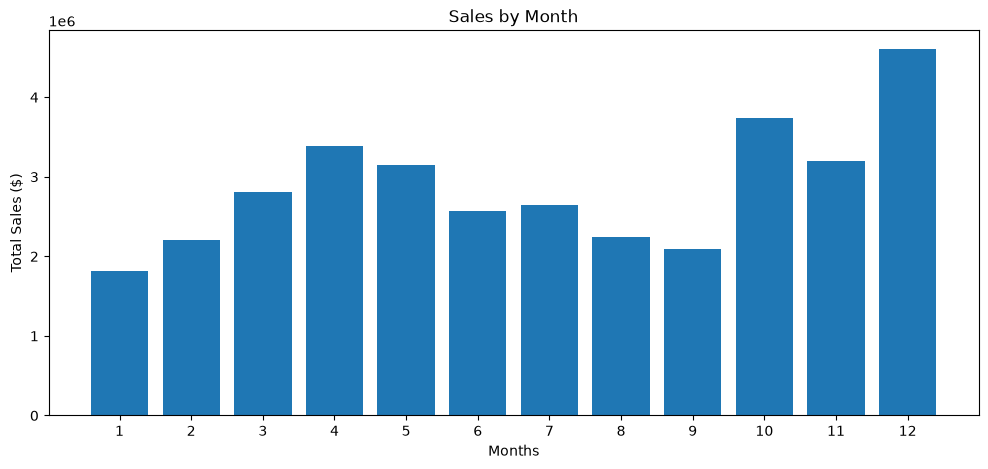

In total, the month generates the highest revenue is 12 with $4608295.7
In total, the month generates the highest revenue is 1 with $1821413.16


In [31]:
import matplotlib.pyplot as plt
monthly_sales = transaction_df.groupby("Month")["Sales"].sum().reset_index()
plt.subplots(figsize=(12,5))
plt.bar(monthly_sales["Month"], monthly_sales["Sales"])
plt.xlabel("Months")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1, 13))
plt.title("Sales by Month")
plt.show()
reversed_sorted_monthly_sales = monthly_sales.sort_values("Sales", ascending=False)
print(f"In total, the month generates the highest revenue is {reversed_sorted_monthly_sales["Month"].iloc[0]} with ${reversed_sorted_monthly_sales["Sales"].iloc[0]}")
print(f"In total, the month generates the highest revenue is {reversed_sorted_monthly_sales["Month"].iloc[-1]} with ${reversed_sorted_monthly_sales["Sales"].iloc[-1]}")

2. Which city contributes the most sales?

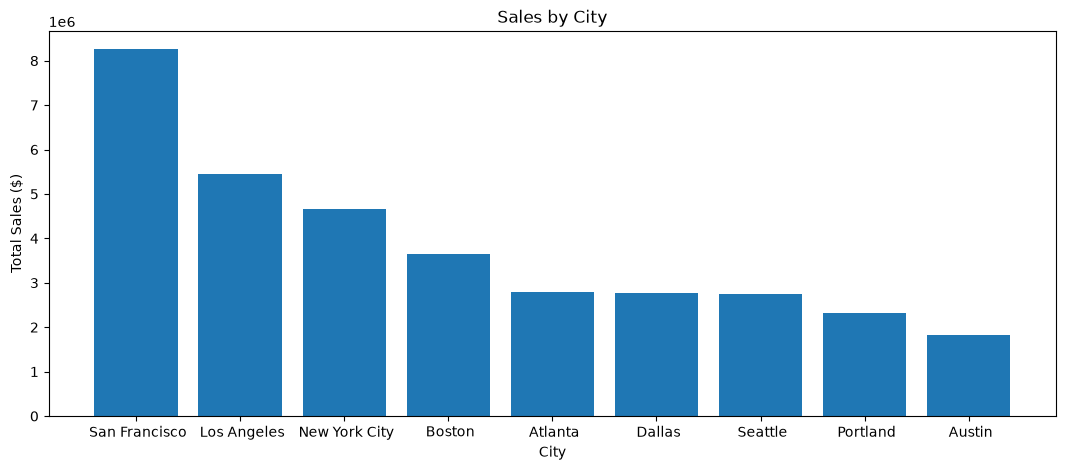

In total, The city contributes the most sales is  San Francisco with $8254744
In total, The city contributes the least sales is  Austin with $1818044


In [32]:
city_sales =  transaction_df.groupby("City")["Sales"].sum().reset_index(name="Sales")
city_sales.sort_values("Sales", ascending=False, inplace=True)
plt.subplots(figsize=(13,5))
plt.bar(city_sales["City"], city_sales["Sales"])
plt.xlabel("City")
plt.ylabel("Total Sales ($)")
plt.title("Sales by City")
plt.show()
print(f"In total, The city contributes the most sales is {city_sales["City"].iloc[0]} with ${round(city_sales["Sales"].iloc[0])}")
print(f"In total, The city contributes the least sales is {city_sales["City"].iloc[-1]} with ${round(city_sales["Sales"].iloc[-1])}")


3. Which products have the highest quantity sold and revenue contribution?

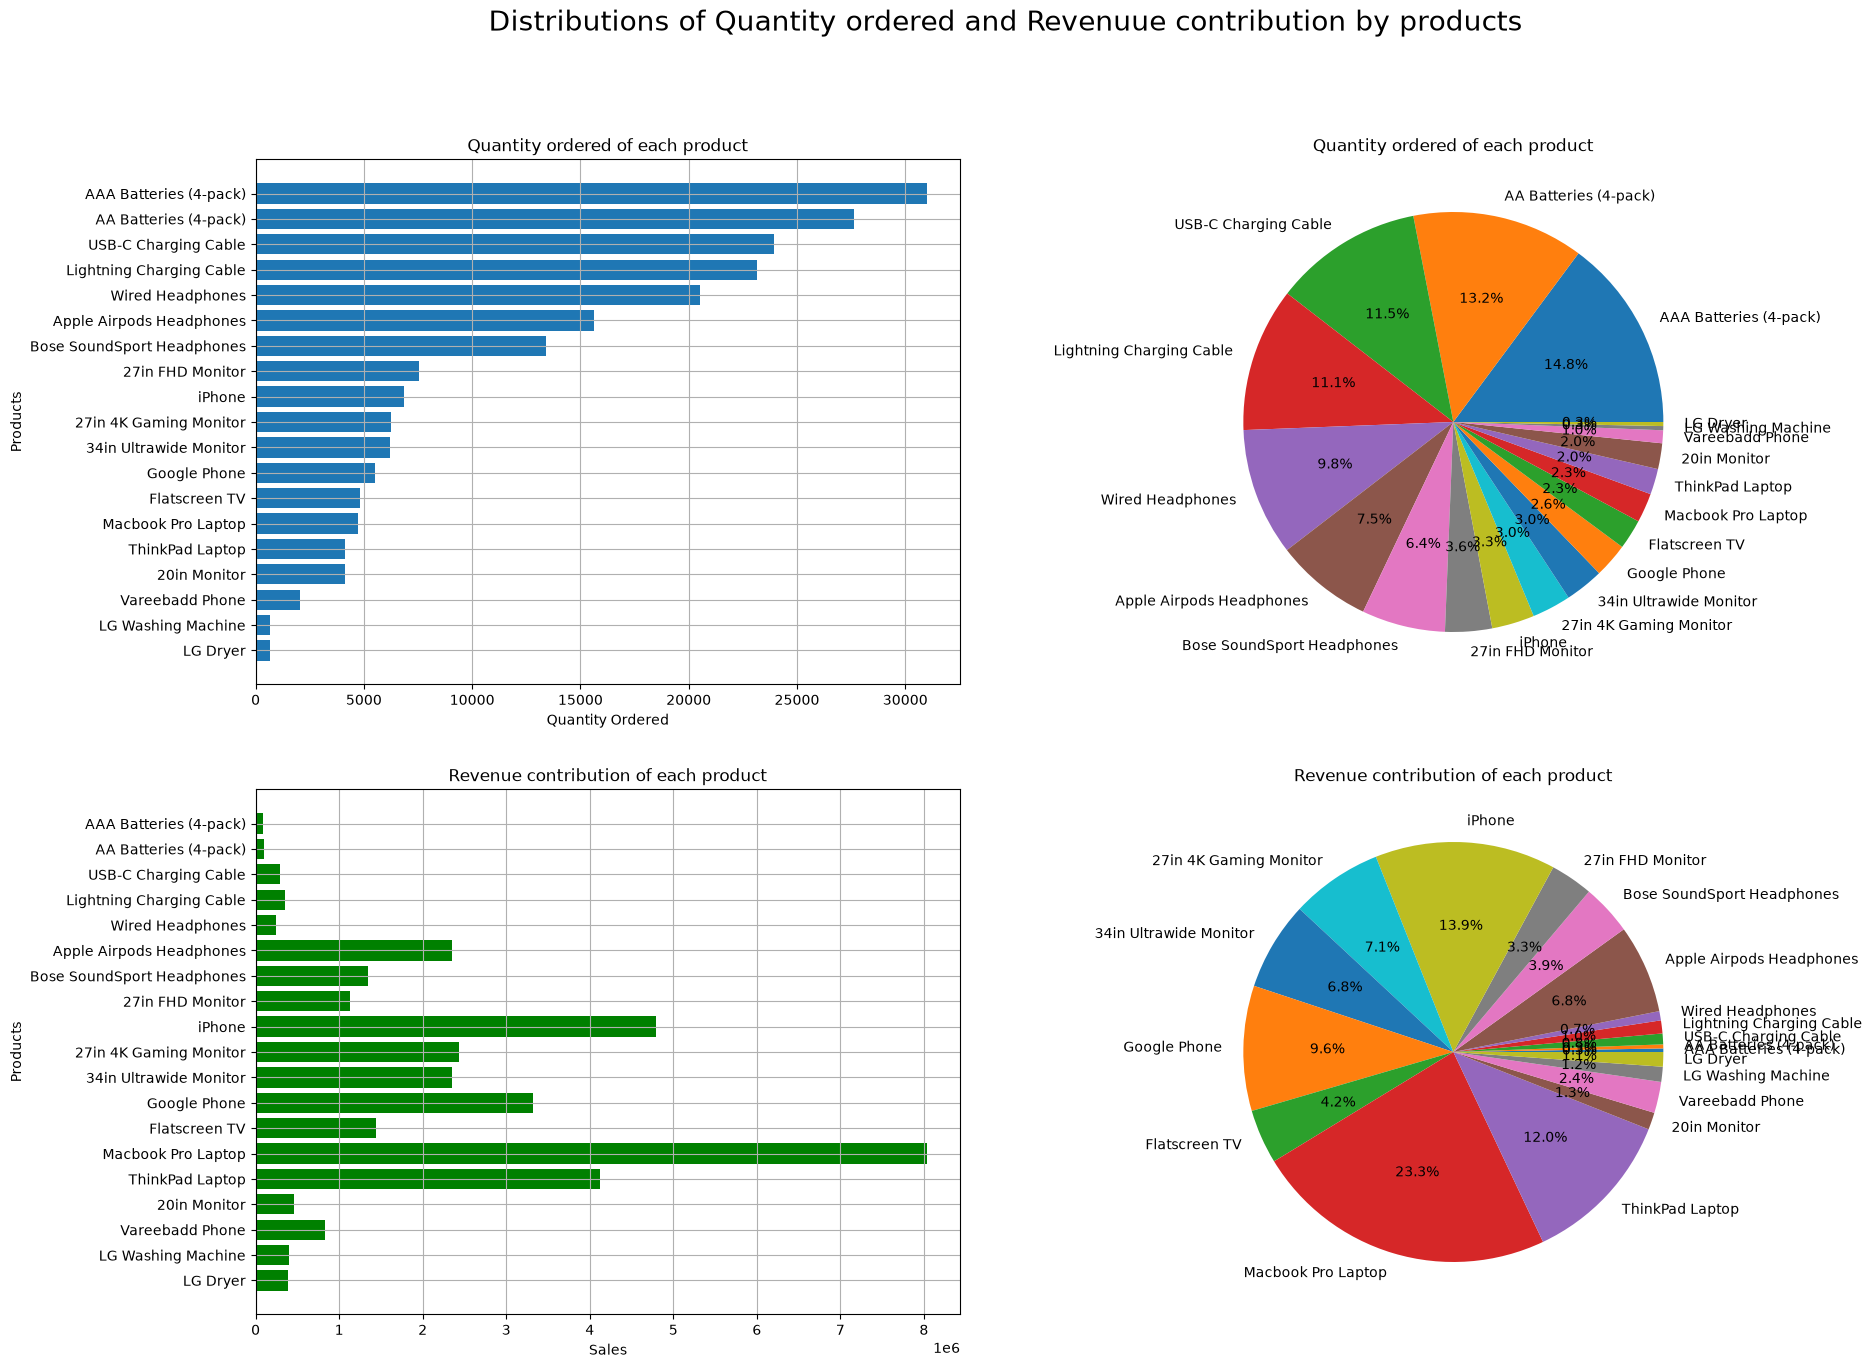

The products have the highest quantity sold is AAA Batteries (4-pack) with 30986 sold products which is 14.84% of total quantity ordered.
AAA Batteries (4-pack)'s revenue contribution is $92648 which is 0.27% of total revenue.

The products have the lowest quantity sold is LG Dryer with 646 sold products which is 0.31% of total quantity ordered.
LG Dryer's revenue contribution is $387600 which is 1.12% of total revenue.

The products have the highest revenue contribution is: Macbook Pro Laptop with $8032500.0 which is 23.31% of total revenue.
There are 4725 sold Macbook Pro Laptop which is 2.26% of total quantity ordered.

The products have the lowest revenue contribution is: AAA Batteries (4-pack) with $92648.14 which is 0.27% of total revenue.
There are 30986 sold AAA Batteries (4-pack) which is 14.84% of total quantity ordered.


In [43]:
products_df = transaction_df.groupby("Product").agg({
    "Quantity Ordered": "sum",
    "Sales": "sum",
    "Price Each": "first"
}).reset_index()
products_df["Quantity Ordered Proportion"] = round((products_df["Quantity Ordered"] / products_df["Quantity Ordered"].sum()) * 100, 2)
products_df["Sales Proportion"] = round((products_df["Sales"] / products_df["Sales"].sum()) * 100, 2)
products_df.sort_values("Quantity Ordered", ascending=False, inplace=True)

# Visualisation
fig, ax = plt.subplots(2, 2, figsize=(20, 15))
ax[0, 0].barh(products_df["Product"], products_df["Quantity Ordered"])
ax[0, 0].invert_yaxis()
ax[0, 0].grid(True)
ax[0, 0].set_xlabel("Quantity Ordered")
ax[0, 0].set_ylabel("Products")
ax[0, 0].set_title("Quantity ordered of each product")

ax[0, 1].pie(products_df["Quantity Ordered Proportion"], labels=products_df["Product"], autopct="%1.1f%%")
ax[0, 1].set_title("Quantity ordered of each product")

ax[1, 0].barh(products_df["Product"], products_df["Sales"], color="green")
ax[1, 0].invert_yaxis()
ax[1, 0].grid(True)
ax[1, 0].set_xlabel("Sales")
ax[1, 0].set_ylabel("Products")
ax[1, 0].set_title("Revenue contribution of each product")

ax[1, 1].pie(products_df["Sales Proportion"], labels=products_df["Product"], autopct="%1.1f%%")
ax[1, 1].set_title("Revenue contribution of each product")
plt.suptitle("Distributions of Quantity ordered and Revenuue contribution by products", fontsize=20)
plt.show()
#

# Quantity ordered products
print(f"The products have the highest quantity sold is {products_df["Product"].iloc[0]} with {products_df["Quantity Ordered"].iloc[0]} sold products which is {(products_df["Quantity Ordered Proportion"].iloc[0])}% of total quantity ordered.")
print(f"{products_df["Product"].iloc[0]}'s revenue contribution is ${round(products_df["Sales"].iloc[0])} which is {products_df["Sales Proportion"].iloc[0]}% of total revenue.\n")

print(f"The products have the lowest quantity sold is {products_df["Product"].iloc[-1]} with {products_df["Quantity Ordered"].iloc[-1]} sold products which is {(products_df["Quantity Ordered Proportion"].iloc[-1])}% of total quantity ordered.")
print(f"{products_df["Product"].iloc[-1]}'s revenue contribution is ${round(products_df["Sales"].iloc[-1])} which is {products_df["Sales Proportion"].iloc[-1]}% of total revenue.\n")

# Revenue contribution products
print(f"The products have the highest revenue contribution is: {products_df.loc[products_df["Sales"].idxmax(), "Product"]} with ${products_df["Sales"].max()} which is {products_df["Sales Proportion"].max()}% of total revenue.")
print(f"There are {products_df.loc[products_df["Sales"].idxmax(), "Quantity Ordered"]} sold {products_df.loc[products_df["Sales"].idxmax(), "Product"]} which is {products_df.loc[products_df["Sales"].idxmax(), "Quantity Ordered Proportion"]}% of total quantity ordered.")

print(f"\nThe products have the lowest revenue contribution is: {products_df.loc[products_df["Sales"].idxmin(), "Product"]} with ${products_df["Sales"].min()} which is {products_df["Sales Proportion"].min()}% of total revenue.")
print(f"There are {products_df.loc[products_df["Sales"].idxmin(), "Quantity Ordered"]} sold {products_df.loc[products_df["Sales"].idxmin(), "Product"]} which is {products_df.loc[products_df["Sales"].idxmin(), "Quantity Ordered Proportion"]}% of total quantity ordered.")

4. What time of day has the highest order activity?

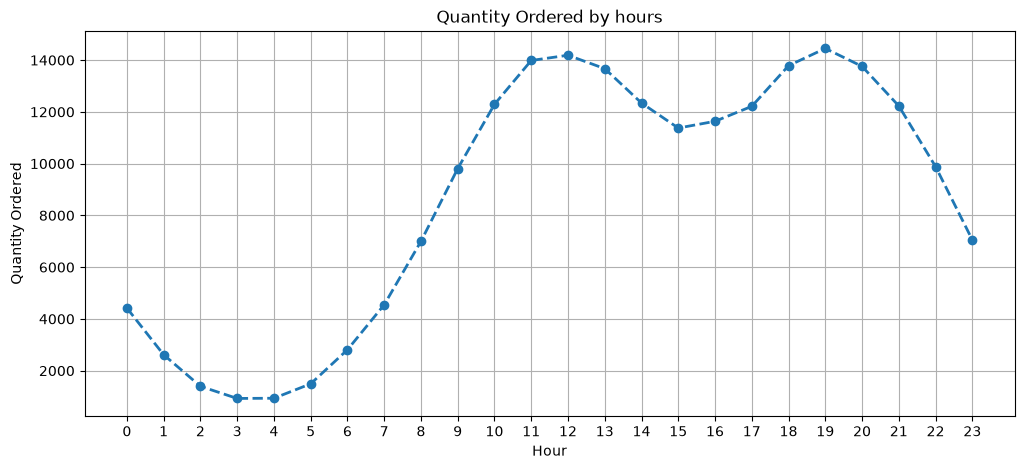

The time of day has the highest order activity is 19 that is 14451 orders
The time of day has the lowest order activity is 3 that is 927 orders


In [44]:
time_order = transaction_df.groupby("Hour")["Quantity Ordered"].sum().reset_index()
plt.subplots(figsize=(12,5))
plt.plot(time_order["Hour"], time_order["Quantity Ordered"], linestyle='--', linewidth=2, marker='o')
plt.xlabel("Hour")
plt.ylabel("Quantity Ordered")
plt.xticks(range(0, 24))
plt.grid(True)
plt.title("Quantity Ordered by hours")
plt.show()
time_order.sort_values("Quantity Ordered", ascending=False, inplace=True)
print(f"The time of day has the highest order activity is {time_order["Hour"].iloc[0]} that is {time_order["Quantity Ordered"].iloc[0]} orders")
print(f"The time of day has the lowest order activity is {time_order["Hour"].iloc[-1]} that is {time_order["Quantity Ordered"].iloc[-1]} orders")

5. Are expensive products sold less frequently?

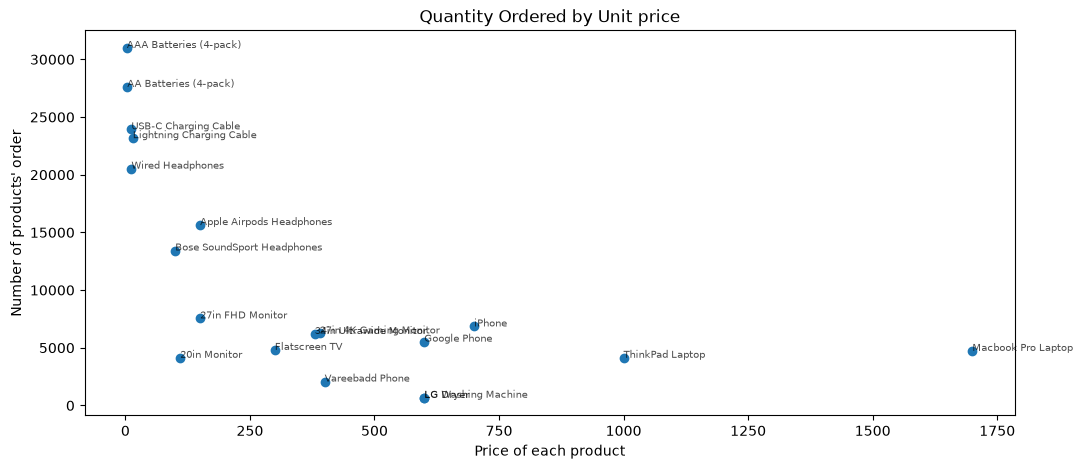

Expensive products sold less frequently


In [35]:
plt.subplots(figsize=(12,5))
plt.scatter(products_df["Price Each"], products_df["Quantity Ordered"])
for i, product in enumerate(products_df["Product"]):
    plt.annotate(product, (products_df["Price Each"].iloc[i], products_df["Quantity Ordered"].iloc[i]), fontsize=7, alpha=0.7)
plt.xlabel("Price of each product")
plt.ylabel("Number of products' order")
plt.title("Quantity Ordered by Unit price")
plt.show()
print("Expensive products sold less frequently")

6. Which products are frequently purchased together?

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

order_df = transaction_df.groupby("Order ID")["Product"].apply(list).reset_index(name="Items")
print("Shape of order_df:", order_df.shape)
more_than_1 = order_df[order_df["Items"].apply(len) >= 2]
print("Shape of more_than_1:", more_than_1.shape)


transaction_encoder = TransactionEncoder()
transaction_encoder_array = transaction_encoder.fit_transform(more_than_1["Items"])
items_together_df = pd.DataFrame(transaction_encoder_array, columns=transaction_encoder.columns_)

frequent_itemsets = apriori(items_together_df, min_support=0.001, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False, inplace=True)
frequent_itemsets

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Sort the rules by lift in descending order
rules.sort_values(by="lift", ascending=False, inplace=True)

# Review the top 10 rules based on lift
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)


Shape of order_df: (178437, 2)
Shape of more_than_1: (6879, 2)


,antecedents,consequents,support,confidence,lift
0,frozenset({Lightning Charging Cable}),frozenset({iPhone}),0.146969,0.585069,2.159170
1,frozenset({iPhone}),frozenset({Lightning Charging Cable}),0.146969,0.542382,2.159170
10,frozenset({Vareebadd Phone}),frozenset({USB-C Charging Cable}),0.053496,0.612313,2.084166
11,frozenset({USB-C Charging Cable}),frozenset({Vareebadd Phone}),0.053496,0.182088,2.084166
2,frozenset({USB-C Charging Cable}),frozenset({Google Phone}),0.144934,0.493320,2.078107
3,frozenset({Google Phone}),frozenset({USB-C Charging Cable}),0.144934,0.610533,2.078107
52,frozenset({27in 4K Gaming Monitor}),frozenset({Macbook Pro Laptop}),0.001890,0.053942,1.952981
53,frozenset({Macbook Pro Laptop}),frozenset({27in 4K Gaming Monitor}),0.001890,0.068421,1.952981
30,"frozenset({USB-C Charging Cable, Wired Headpho...",frozenset({Vareebadd Phone}),0.004797,0.162562,1.860667
31,frozenset({Vareebadd Phone}),"frozenset({USB-C Charging Cable, Wired Headpho...",0.004797,0.054908,1.860667


7. Can machine learning models predict sales revenue accurately?

               Model          MSE       RMSE        R2
0  Linear Regression   184.318766  13.576405  0.998408
1      Random Forest   263.616476  16.236270  0.997723
2      Decision Tree   303.630224  17.424988  0.997377
3  Gradient Boosting   656.746598  25.627068  0.994327
4              Lasso  1186.706459  34.448606  0.989749


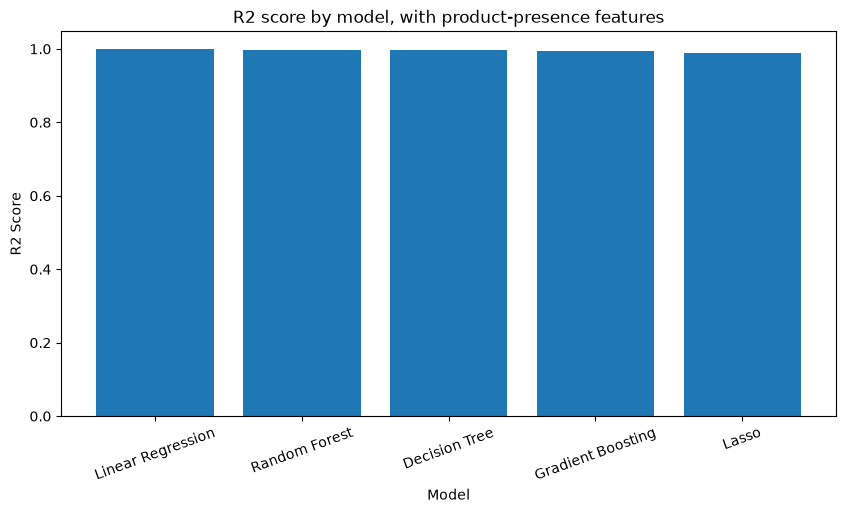


Best performing model: Linear Regression (R2 = 0.9984)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from mlxtend.preprocessing import TransactionEncoder as TE_Order


## Build a boolean "which products are in this order" matrix, for every order
# Group data by "Order ID"
order_level_df = transaction_df.groupby("Order ID").agg(
    Sales=("Sales", "sum"),
    Month=("Month", "first"),
    Hour=("Hour", "first"),
    City=("City", "first"),
    Num_Items=("Product", "count")
).reset_index()
#  Aggregate the "Product" variable into a list
order_items_df = transaction_df.groupby("Order ID")["Product"].apply(list).reset_index(name="Items")

# Turn the list into a boolean matrix
te_order = TE_Order()
te_array = te_order.fit_transform(order_items_df["Items"])

# Build a DataFrame from the boolean matrix
product_presence_df = pd.DataFrame(te_array, columns=list(te_order.columns_))
product_presence_df.insert(0, "Order ID", order_items_df["Order ID"])

# Merge product-presence features onto the order-level dataset
order_level_enhanced_df = order_level_df.merge(product_presence_df, on="Order ID")
product_columns = list(te_order.columns_)

# Split the data into training and test sets
X = order_level_enhanced_df[["Month", "Hour", "City", "Num_Items"] + product_columns]
y = order_level_enhanced_df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

## Data preprocessing: 
# Define preprocessing for numeric features 
numeric_features = ["Month", "Hour", "Num_Items"]
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

# Define preprocessing for categorical features (encode them)
categorical_features = ["City"]
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

# Product columns are already 0/1, so we pass them straight through the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough")

# Models:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=1),
    "Random Forest": RandomForestRegressor(random_state=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=1)
}

# Create preprocessing and training pipeline
predictions = []
for model_name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, prediction)
    predictions.append({"Model": model_name, "MSE": mse, "RMSE": rmse, "R2": r2})

# Create a DataFrame to display and compare the results
prediction_df = pd.DataFrame(predictions).sort_values("R2", ascending=False).reset_index(drop=True)
print(prediction_df)

# Visualise model comparison
plt.subplots(figsize=(10,5))
plt.bar(prediction_df["Model"], prediction_df["R2"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("R2 score by model, with product-presence features")
plt.xticks(rotation=20)
plt.show()


best_model_name = prediction_df.iloc[0]["Model"]
print(f"\nBest performing model: {best_model_name}")


8. Which features are most important in predicting sales?

In [39]:
features = Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=2))])
features.fit(X_train, y_train)

feature_names = features.named_steps["prep"].get_feature_names_out()
importance = features.named_steps["model"].feature_importances_

features_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
features_df.sort_values(by="Importance", ascending=False, inplace=True)
print(features_df.head(10))

                     Feature  Importance
2             num__Num_Items    0.966053
1                  num__Hour    0.015420
0                 num__Month    0.009477
9        cat__City_ Portland    0.002014
10  cat__City_ San Francisco    0.001269
7     cat__City_ Los Angeles    0.001115
8   cat__City_ New York City    0.001094
5          cat__City_ Boston    0.000930
4          cat__City_ Austin    0.000926
3         cat__City_ Atlanta    0.000704
